# Generation of statistics for heatwave indices, by station, showing a map

Author: Hugo Carrillo

Creation: July 2024

Last Modified: November 2025

Steps:
1. We show the selected stations in a map.
2. We read the indices HWN, HWF, HWD, HWM, HWA for each year and stations, produced by the previous notebook.
3. We produce figures for the trends of each heatwave index for each station in a map.
4. We produce a latex code that shows a table with the slopes, r2, and p-values for each station and index.

In [15]:
#%pip install fiona==1.9.5
import sys
import os

import pandas as pd
import pickle


import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) # Suppress specific RuntimeWarnings

In [16]:
try:
    import geopandas as geo
except:
    %pip install geopandas=="0.13.2"
    import geopandas as geo

from shapely.geometry import box

from shapely.affinity import translate


In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Parameters


In [18]:
METADATA_PATH_AND_FILENAME = 'data/original/cimis_metadata.csv'
CLEANED_DATA_PATH = 'data/cleaned/'
GEO_DATA_PATH = 'geo_data/'
MY_FUNCTIONS_PATH = '../functions/'
AUX_DATA_FOLDER = 'data/aux/'
PLOTS_FOLDER = 'plots/'
SHAPEFILE_NAME = 'ca_counties.zip'


# Rectangle for California
min_lon, min_lat, max_lon, max_lat = -125.0, 32.5, -113.8, 42.3#42

In [19]:
import fiona
print("Fiona version:", fiona.__version__)
print("GeoPandas version:", geo.__version__)

Fiona version: 1.9.5
GeoPandas version: 0.13.2


In [20]:
# Add the folder to the Python path
folder_path = os.path.abspath(MY_FUNCTIONS_PATH)
sys.path.insert(0, folder_path)

from HWFunctionsWithMaps import (
    KoeppenMapWithStations,
    plot_trends_years_all_indices
)

# Table 1: Information of the selected stations

In [21]:
stations = pd.read_csv(METADATA_PATH_AND_FILENAME)
statlist= [91, 90, 43, 6, 47, 70, 35, 39, 5, 52, 62] #sorted from N to S


stations = stations[stations['StationNbr'].isin(statlist)]
stations['latitude'] = stations['HmsLatitude'].apply(lambda x: x.split('/')[-1].strip())
stations['longitude'] = stations['HmsLongitude'].apply(lambda x: x.split('/')[-1].strip())

stations = stations.sort_values(by='latitude', ascending=False) #it sorts the stations metadata from N to S

# Generate the code for a table in LaTeX
# This table show information of the stations
latex_code = stations[['Name', 'latitude', 'longitude', 'Elevation']].to_latex(index=False).replace("\\\\", "\\")
print(latex_code)

\begin{tabular}{lllr}
\toprule
Name & latitude & longitude & Elevation \
\midrule
Tulelake FS & 41.958869 & -121.472370 & 4035 \
Alturas & 41.438214 & -120.480310 & 4405 \
McArthur & 41.063767 & -121.456020 & 3310 \
Davis & 38.535694 & -121.776360 & 60 \
Brentwood & 37.928258 & -121.6599 & 45 \
Manteca & 37.834822 & -121.223190 & 33 \
Bishop & 37.358514 & -118.405530 & 4170 \
Parlier & 36.597444 & -119.504040 & 337 \
Shafter & 35.532556 & -119.281790 & 360 \
San Luis Obispo & 35.305442 & -120.661780 & 330 \
Temecula & 33.486650 & -117.228270 & 1420 \
\bottomrule
\end{tabular}



# Reading geographical data

In [22]:
cal_map = geo.read_file(GEO_DATA_PATH + SHAPEFILE_NAME)


if cal_map.crs != 'EPSG:4326':
    cal_map = cal_map.to_crs('EPSG:4326')

# Clip the GeoDataFrame to the bounding box
bbox = box(min_lon, min_lat, max_lon, max_lat)
clipped_gdf = cal_map.clip(bbox)


# Koppen map
gdf_KM = geo.read_file(GEO_DATA_PATH + 'KG_1986-2010.zip')
bbox_KM = box(min_lon, min_lat, max_lon, max_lat)

# Clip the GeoDataFrame to the bounding box
gdf_KM = gdf_KM.clip(bbox)

# Plot 1: Köppen map with stations

Color map: {5.0: '#CC8D14', 6.0: '#CCAA54', 7.0: '#FFCC00', 8.0: '#FFFF64', 10.0: '#005000', 12.0: '#96FF00', 13.0: '#00D700', 14.0: '#00AA00', 19.0: '#820082', 20.0: '#C800C8', 23.0: '#8C8C8C', 24.0: '#BEBEBE', 31.0: '#64FFFF', 32.0: '#F5FFFF'}


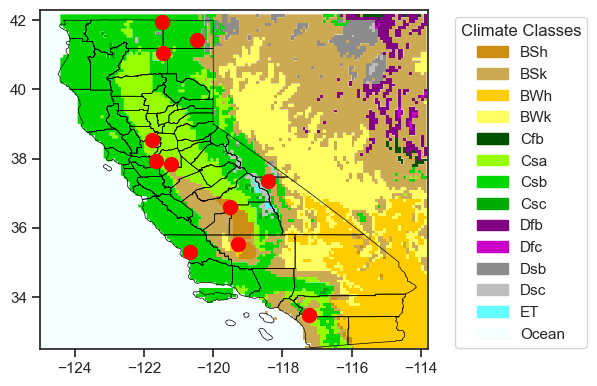

In [23]:
KoeppenMapWithStations(stations, clipped_gdf, gdf_KM, min_lon, min_lat, max_lon, max_lat,
                path = PLOTS_FOLDER, filename = 'KoeppenWithStationsCentralCalifornia.pdf')

# Reading the heatwave indices summary

In [24]:
filename = 'hw_Cal_summary.pkl'
with open(AUX_DATA_FOLDER + filename, 'rb') as f:
    hw_Cal_summary = pickle.load(f)

In [25]:
hw_Cal_summary.keys()

dict_keys(['DJF', 'MAM', 'JJA', 'SON', 'Total'])

# Plot 2: Trends in each station

HWN
HWF
HWD
HWM
HWA


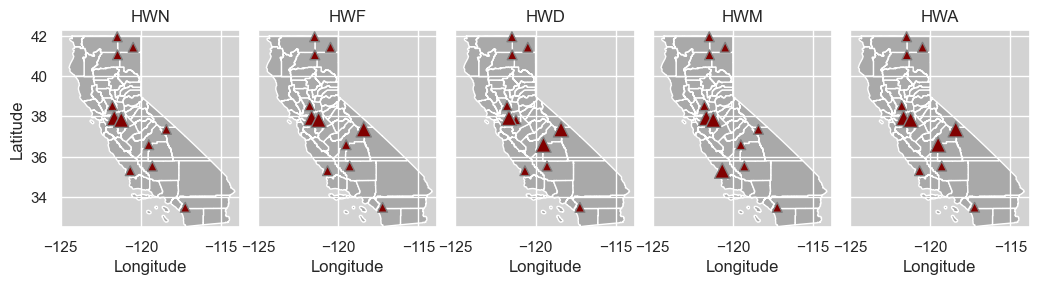

In [26]:
start = 1989
end = 2024

fsize = [12.5, 3] #figsize
pos_adj = 1.2 # It helps to adjust the distance between subplots. Values around 1 seem to be ok.
trends, r_values, p_values = plot_trends_years_all_indices(start,end,hw_Cal_summary['Total']['MeteoChile']['CDA'],
                                stations,cal_map, min_lon, min_lat, max_lon, max_lat,
                                'MeteoChile', vmin=-1.45,vmax=1.45, fig_PATH=PLOTS_FOLDER, fsize = fsize,
                                wspace=0.1, format = 'png', pos_adj=pos_adj, 
                                trend_type = 'u-test', divpoint = 2010, signlevel = 0.05)